<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Random%20Forest%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   number_courses  time_study   Marks
0               3       4.508  19.202
1               4       0.096   7.734
2               4       3.133  13.811
3               6       7.909  53.018
4               8       7.811  55.299

Dataset Shape:
(100, 3)

Columns:
Index(['number_courses', 'time_study', 'Marks'], dtype='object')

Missing Values:
number_courses    0
time_study        0
Marks             0
dtype: int64

Training Data: (80, 2)
Testing Data: (20, 2)

Random Forest model trained successfully!

Predicted Marks:
[16.44918 35.56641 16.92413 10.42055 11.0462  50.95797 12.55124 52.14082
 43.89374 20.07702 50.99347 22.3653   7.59664 40.89446 23.16644 52.75318
 38.48433 36.21883 22.96653 10.07079]

Actual vs Predicted:
    Actual Marks  Predicted Marks
0         16.106         16.44918
1         36.653         35.56641
2         16.606         16.92413
3          8.924         10.42055
4          9.742         11.04620
5         51.142         50.95797
6         12.209 

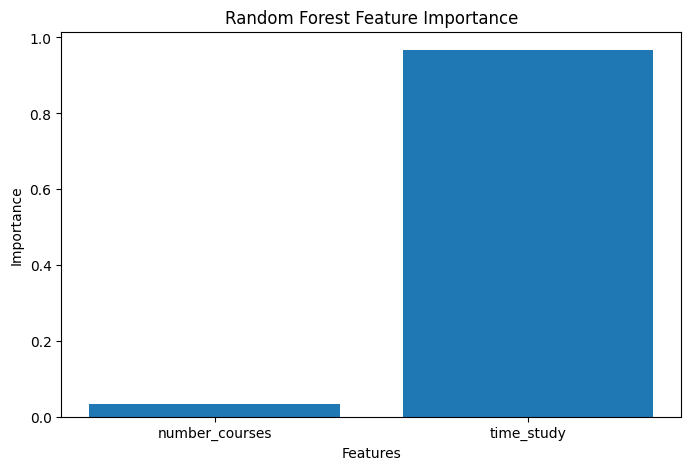

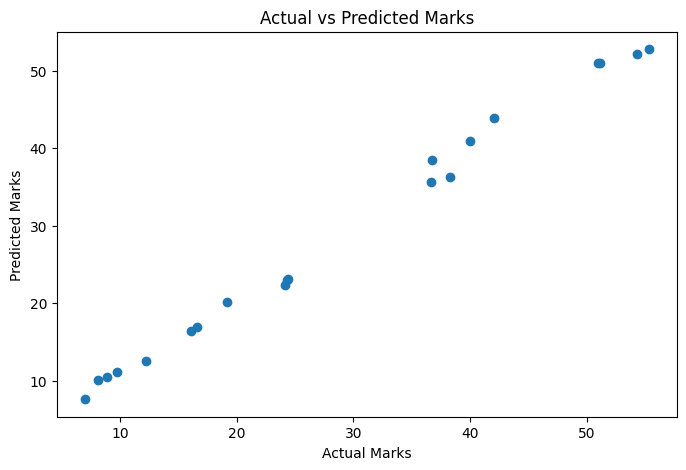


Predicted Marks for New Student:
20.691909999999986


In [2]:
# ============================================
# RANDOM FOREST REGRESSION
# STUDENT MARKS DATASET
# ============================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================
# 2. Load Dataset
# ============================================

df = pd.read_csv("Student_Marks.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

# ============================================
# 3. Check Missing Values
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================
# 4. Define X and Y
# ============================================

X = df[["number_courses", "time_study"]]

y = df["Marks"]

# ============================================
# 5. Split Dataset
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ============================================
# 6. Create Random Forest Model
# ============================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# ============================================
# 7. Train Model
# ============================================

model.fit(X_train, y_train)

print("\nRandom Forest model trained successfully!")

# ============================================
# 8. Make Predictions
# ============================================

y_pred = model.predict(X_test)

print("\nPredicted Marks:")
print(y_pred)

# ============================================
# 9. Actual vs Predicted
# ============================================

comparison = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

print("\nActual vs Predicted:")
print(comparison)

# ============================================
# 10. Model Evaluation
# ============================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score:", r2)

# ============================================
# 11. Feature Importance
# ============================================

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

print("\nFeature Importance:")
print(feature_importance)

# ============================================
# 12. Feature Importance Graph
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

# ============================================
# 13. Actual vs Predicted Graph
# ============================================

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.show()

# ============================================
# 14. Predict Marks for New Student
# ============================================

new_student = pd.DataFrame({
    "number_courses": [5],
    "time_study": [4.5]
})

prediction = model.predict(new_student)

print("\nPredicted Marks for New Student:")
print(prediction[0])